In [1]:
import pickle, math, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
from utils import Ontology

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

DATA_ROOT = Path('data')
ONTS = ['ec', 'mf', 'bp', 'cc']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ── Frequency bucket boundaries ───────────────────────────
HEAD_THR, TAIL_THR = 100, 30

# ── Colours ───────────────────────────────────────────────
BCOLORS = {
    'head': '#2196F3', 'mid': '#FF9800', 'tail': '#F44336'
}
MODEL_COLORS = {
    'FreqPrior': '#78909C',
    'InterPro2GO': '#AB47BC',
    'ESM2-kNN': '#26A69A',
    'MLP-BCE': '#EF5350',
    'DGPRO-PU': '#1565C0',
}

# ================================================================
# Data loading
# ================================================================
def load_ont(ont):
    """Load train/test splits and term vocabulary for one ontology."""
    terms    = pickle.load(open(DATA_ROOT / ont / 'terms.pkl', 'rb'))['gos'].tolist()
    term2idx = {g: i for i, g in enumerate(terms)}
    K        = len(terms)

    def _load(split):
        df = pickle.load(open(DATA_ROOT / ont / f'{split}_data.pkl', 'rb'))
        X  = torch.stack(df['esm2'].tolist()).float()
        Y  = torch.zeros(len(df), K)
        for i, anns in enumerate(df['prop_annotations']):
            for g in anns:
                if g in term2idx: Y[i, term2idx[g]] = 1.0
        Y_exp = torch.zeros(len(df), K)
        for i, anns in enumerate(df['exp_annotations']):
            for g in anns:
                if g in term2idx: Y_exp[i, term2idx[g]] = 1.0
        return df, X, Y, Y_exp

    train_df, Xtr, Ytr, Ytr_exp = _load('train')
    valid_df, Xva, Yva, Yva_exp = _load('valid')
    test_df,  Xte, Yte, Yte_exp = _load('test')
    
    
    freq = Ytr.sum(dim=0).numpy().astype(int)
    valid = freq > 0
    masks = {
        'head': (freq >= HEAD_THR),
        'mid':  (freq >= TAIL_THR) & (freq < HEAD_THR),
        'tail': (freq < TAIL_THR) & valid,
    }
    
    '''
    freq = Ytr.sum(dim=0).numpy().astype(int)
    valid_idx = np.where(freq > 0)[0]
    freq_valid = freq[valid_idx]
    sorted_idx = valid_idx[np.argsort(freq_valid)]
    n = len(sorted_idx)
    n1 = n // 3
    n2 = 2 * n // 3
    tail_idx = sorted_idx[:n1]
    mid_idx  = sorted_idx[n1:n2]
    head_idx = sorted_idx[n2:]
    mask_head = np.zeros_like(freq, dtype=bool)
    mask_mid  = np.zeros_like(freq, dtype=bool)
    mask_tail = np.zeros_like(freq, dtype=bool)
    mask_head[head_idx] = True
    mask_mid[mid_idx]   = True
    mask_tail[tail_idx] = True
    masks = {
        'head': mask_head,
        'mid':  mask_mid,
        'tail': mask_tail
    }
    '''

    return dict(terms=terms, term2idx=term2idx, K=K,
                train_df=train_df, valid_df=valid_df, test_df=test_df,
                Xtr=Xtr, Ytr=Ytr, Ytr_exp=Ytr_exp,
                Xva=Xva, Yva=Yva,
                Xte=Xte, Yte=Yte,
                freq=freq, masks=masks)

def load_ec_ont():
    data = torch.load(DATA_ROOT / "ec_dataset.pt")

    X = data["X"].float()
    Y = data["Y"].float()
    ec2idx = data["ec2idx"]

    terms = list(ec2idx.keys())
    term2idx = ec2idx
    K = Y.shape[1]

    n = X.shape[0]
    n_train = int(0.8 * n)
    n_valid = int(0.1 * n)

    Xtr, Ytr = X[:n_train], Y[:n_train]
    Xva, Yva = X[n_train:n_train+n_valid], Y[n_train:n_train+n_valid]
    Xte, Yte = X[n_train+n_valid:], Y[n_train+n_valid:]

    freq = Ytr.sum(dim=0).numpy().astype(int)
    valid = freq > 0

    masks = {
        "head": freq >= HEAD_THR,
        "mid":  (freq >= TAIL_THR) & (freq < HEAD_THR),
        "tail": (freq < TAIL_THR) & valid,
    }

    return dict(
        terms=terms,
        term2idx=term2idx,
        K=K,
        train_df=None,
        valid_df=None,
        test_df=None,
        Xtr=Xtr,
        Ytr=Ytr,
        Xva=Xva,
        Yva=Yva,
        Xte=Xte,
        Yte=Yte,
        freq=freq,
        masks=masks
    )


print('Loading data...')
ONT_DATA = {}
for ont in ONTS:
    if ont == "ec":
        ONT_DATA[ont] = load_ec_ont()
    else:
        ONT_DATA[ont] = load_ont(ont)
go_rels = Ontology("data/go-basic.obo", with_rels=True)
print('Done.')

Device: cuda
Loading data...
Done.


In [2]:
# ================================================================
# Shared evaluation functions
# ================================================================
def propagate_pred_scores_official(probs, go_rels, term2idx):
    probs_prop = probs.copy()

    for go_id, j in term2idx.items():
        score_vec = probs[:, j]
        for anc in go_rels.get_ancestors(go_id):
            if anc in term2idx:
                ai = term2idx[anc]
                probs_prop[:, ai] = np.maximum(probs_prop[:, ai], score_vec)

    return probs_prop

def compute_fmax_fast(y_score, y_true):
    """Per-term Fmax (vectorized)."""
    P = y_true.sum()
    if P == 0:
        return np.nan
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    recall    = tp / P
    precision = tp / (tp + fp + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return float(np.max(f1))

def macro_fmax(preds, labels, mask):
    vals = [compute_fmax_fast(preds[:, k], labels[:, k])
            for k in np.where(mask)[0]]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else 0.0

def macro_aupr(preds, labels, mask):
    vals = []
    for k in np.where(mask)[0]:
        if labels[:, k].sum() > 0:
            vals.append(average_precision_score(labels[:, k], preds[:, k]))
    return float(np.mean(vals)) if vals else 0.0

def recall_at_k(preds, labels, mask, k=20):
    vals = []
    for t in np.where(mask)[0]:
        y = labels[:, t]
        if y.sum() == 0: continue
        topk = np.argsort(-preds[:, t])[:k]
        vals.append(y[topk].sum() / y.sum())
    return float(np.mean(vals)) if vals else 0.0

def eval_all_buckets(preds_np, labels_np, masks, k=20):
    """Return a dict of metrics for each frequency bucket."""
    results = {}
    for bucket, mask in masks.items():
        results[bucket] = {
            'Macro-Fmax':  macro_fmax(preds_np, labels_np, mask),
            'Term-AUPR':   macro_aupr(preds_np, labels_np, mask),
            f'Recall@{k}': recall_at_k(preds_np, labels_np, mask, k),
        }
    return results

def fmax_official(probs, labels, thresholds=np.linspace(0, 1, 101)):
    label_sets = [set(np.where(labels[i] == 1)[0]) for i in range(labels.shape[0])]
    best = 0.0
    for t in thresholds:
        Ps, Rs = [], []
        for i in range(len(label_sets)):
            pred = set(np.where(probs[i] >= t)[0])
            true = label_sets[i]
            if not pred and not true:
                continue
            tp = len(pred & true)
            fp = len(pred - true)
            fn = len(true - pred)
            if tp + fp > 0:
                Ps.append(tp / (tp + fp))
            if tp + fn > 0:
                Rs.append(tp / (tp + fn))
        if Ps and Rs:
            P, R = np.mean(Ps), np.mean(Rs)
            if P + R > 0:
                best = max(best, 2 * P * R / (P + R))
    return best

def fmax_bucket(preds, labels, mask):
    # Micro-Fmax for a bucket
    preds_sub = preds[:, mask]
    labels_sub = labels[:, mask]
    return fmax_official(preds_sub, labels_sub)

def get_ec_ancestors(ec):
    parts = ec.split(".")
    ancestors = []

    # 例如 1.1.1.1 -> 1, 1.1, 1.1.1
    for i in range(1, len(parts)):
        ancestors.append(".".join(parts[:i]))

    return ancestors


def propagate_ec_scores(preds, term2idx):
    preds_prop = preds.copy()

    for ec, j in term2idx.items():
        score_vec = preds[:, j]

        for anc in get_ec_ancestors(ec):
            if anc in term2idx:
                ai = term2idx[anc]
                preds_prop[:, ai] = np.maximum(preds_prop[:, ai], score_vec)

    return preds_prop

In [3]:
# ================================================================
# Result Analysis (2 Tables Version)
# ================================================================

import os
PRED_DIR = "predict_result"
# MODELS  = ['Base', 'tailgr_topk256_topm10']
MODELS  = ['FreqPrior', 'InterPro2GO', 'ESM2-kNN', 'MLP-BCE', 'DGPRO-PU', 'tailgr_topk128_topm10']
# BUCKETS = ['head', 'mid', 'tail']
# METRICS = ['Macro-Fmax', 'Term-AUPR', 'Recall@20']

# ================================================================
# 存结果
# ================================================================
fmax_results = []     # 表1
hmt_results  = []     # 表2
micro_results = []    # 分段 micro

# ================================================================
# 主循环
# ================================================================
for ont in ONTS:
    print(f"\n=== Processing {ont.upper()} ===")

    d = ONT_DATA[ont]
    labels = d['Yte'].numpy()
    masks = d['masks']

    for model in MODELS:
        file_path = f"{PRED_DIR}/{ont}_{model}.csv"

        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        df = pd.read_csv(file_path)
        preds = df.drop(columns=["protein_id"]).values

        if ont == "ec":
            preds = propagate_ec_scores(preds, d["term2idx"])
        else:
            preds = propagate_pred_scores_official(
                preds,
                go_rels,
                d["term2idx"]
            )

        # ========================================================
        # 表1：Official Fmax
        # ========================================================
        fmax_val = fmax_official(preds, labels)
        fmax_results.append({
            "ont": ont.upper(),
            "model": model,
            "Official-Fmax": fmax_val
        })

        # ========================================================
        # 表2：Head / Mid / Tail
        # ========================================================
        bucket_results = eval_all_buckets(preds, labels, masks)
        for bucket in ["head", "mid", "tail"]:
            hmt_results.append({
                "ont": ont.upper(),
                "model": model,
                "bucket": bucket,
                "Macro-Fmax": bucket_results[bucket]["Macro-Fmax"],
                "Recall@20":  bucket_results[bucket]["Recall@20"],
                "Term-AUPR":  bucket_results[bucket]["Term-AUPR"]
            })

        # ========================================================
        # 表3：Micro-Fmax per bucket（MSRep对齐）
        # ========================================================
        for bucket in ["head", "mid", "tail"]:
            micro_val = fmax_bucket(preds, labels, masks[bucket])
            micro_results.append({
                "ont": ont.upper(),
                "model": model,
                "bucket": bucket,
                "Micro-Fmax": micro_val
            })

# ================================================================
# 表1：Official Fmax
# ================================================================
df_fmax = pd.DataFrame(fmax_results)

pivot_fmax = df_fmax.pivot_table(
    index=["ont", "model"],
    values="Official-Fmax"
)

print("\n=== Table 1: Official Fmax ===")
print(pivot_fmax)


# ================================================================
# 表2：Head / Mid / Tail
# ================================================================
df_hmt = pd.DataFrame(hmt_results)

pivot_hmt = df_hmt.pivot_table(
    index=["ont", "model"],
    columns="bucket",
    values=["Macro-Fmax", "Recall@20", "Term-AUPR"]
)

# 👉 展平成一层（论文更清晰）
pivot_hmt.columns = [f"{metric}_{bucket}" for metric, bucket in pivot_hmt.columns]

print("\n=== Table 2: Head / Mid / Tail ===")
print(pivot_hmt)

# ================================================================
# 表3: Micro-Fmax (Head / Mid / Tail)
# ================================================================
df_micro = pd.DataFrame(micro_results)
pivot_micro = df_micro.pivot_table(
    index=["ont", "model"],
    columns="bucket",
    values="Micro-Fmax"
)
pivot_micro = pivot_micro[["head", "mid", "tail"]]

print("\n=== Table 3: Micro-Fmax (Head / Mid / Tail) ===")
print(pivot_micro)


=== Processing EC ===
Missing: predict_result/ec_InterPro2GO.csv

=== Processing MF ===

=== Processing BP ===

=== Processing CC ===

=== Table 1: Official Fmax ===
                           Official-Fmax
ont model                               
BP  DGPRO-PU                    0.360060
    ESM2-kNN                    0.366860
    FreqPrior                   0.298421
    InterPro2GO                 0.495671
    MLP-BCE                     0.319535
    tailgr_topk128_topm10       0.420911
CC  DGPRO-PU                    0.659512
    ESM2-kNN                    0.665007
    FreqPrior                   0.550111
    InterPro2GO                 0.601861
    MLP-BCE                     0.695452
    tailgr_topk128_topm10       0.708587
EC  DGPRO-PU                    0.712277
    ESM2-kNN                    0.507391
    FreqPrior                   0.293892
    MLP-BCE                     0.706968
    tailgr_topk128_topm10       0.750776
MF  DGPRO-PU                    0.515840
    ESM2-kNN 

In [4]:
# ================================================================
# Save Tables
# ================================================================
from pathlib import Path

OUT_DIR = Path("analysis_tables")
OUT_DIR.mkdir(exist_ok=True)

# 保存 Table 1
pivot_fmax.to_csv(OUT_DIR / "table1_official_fmax.csv")
print(f"Saved: {OUT_DIR / 'table1_official_fmax.csv'}")

# 保存 Table 2
pivot_hmt.to_csv(OUT_DIR / "table2_head_mid_tail.csv")
print(f"Saved: {OUT_DIR / 'table2_head_mid_tail.csv'}")

Saved: analysis_tables\table1_official_fmax.csv
Saved: analysis_tables\table2_head_mid_tail.csv


# 进一步分析


=== Figure 1 Data: Stacked Overall Fmax ===
   ont                  model  Overall Fmax  Head-Tail Gap  Fmax_minus_Gap
0   BP               DGPRO-PU      0.360060       0.087387        0.272673
1   BP               ESM2-kNN      0.366860       0.079808        0.287052
2   BP              FreqPrior      0.298421       0.034604        0.263817
3   BP            InterPro2GO      0.495671       0.078745        0.416926
4   BP                MLP-BCE      0.319535       0.076144        0.243391
5   BP  tailgr_topk128_topm10      0.420911       0.076187        0.344724
6   CC               DGPRO-PU      0.659512       0.196701        0.462811
7   CC               ESM2-kNN      0.665007       0.091999        0.573008
8   CC              FreqPrior      0.550111       0.057207        0.492905
9   CC            InterPro2GO      0.601861       0.053741        0.548121
10  CC                MLP-BCE      0.695452       0.073079        0.622374
11  CC  tailgr_topk128_topm10      0.708587       0.041

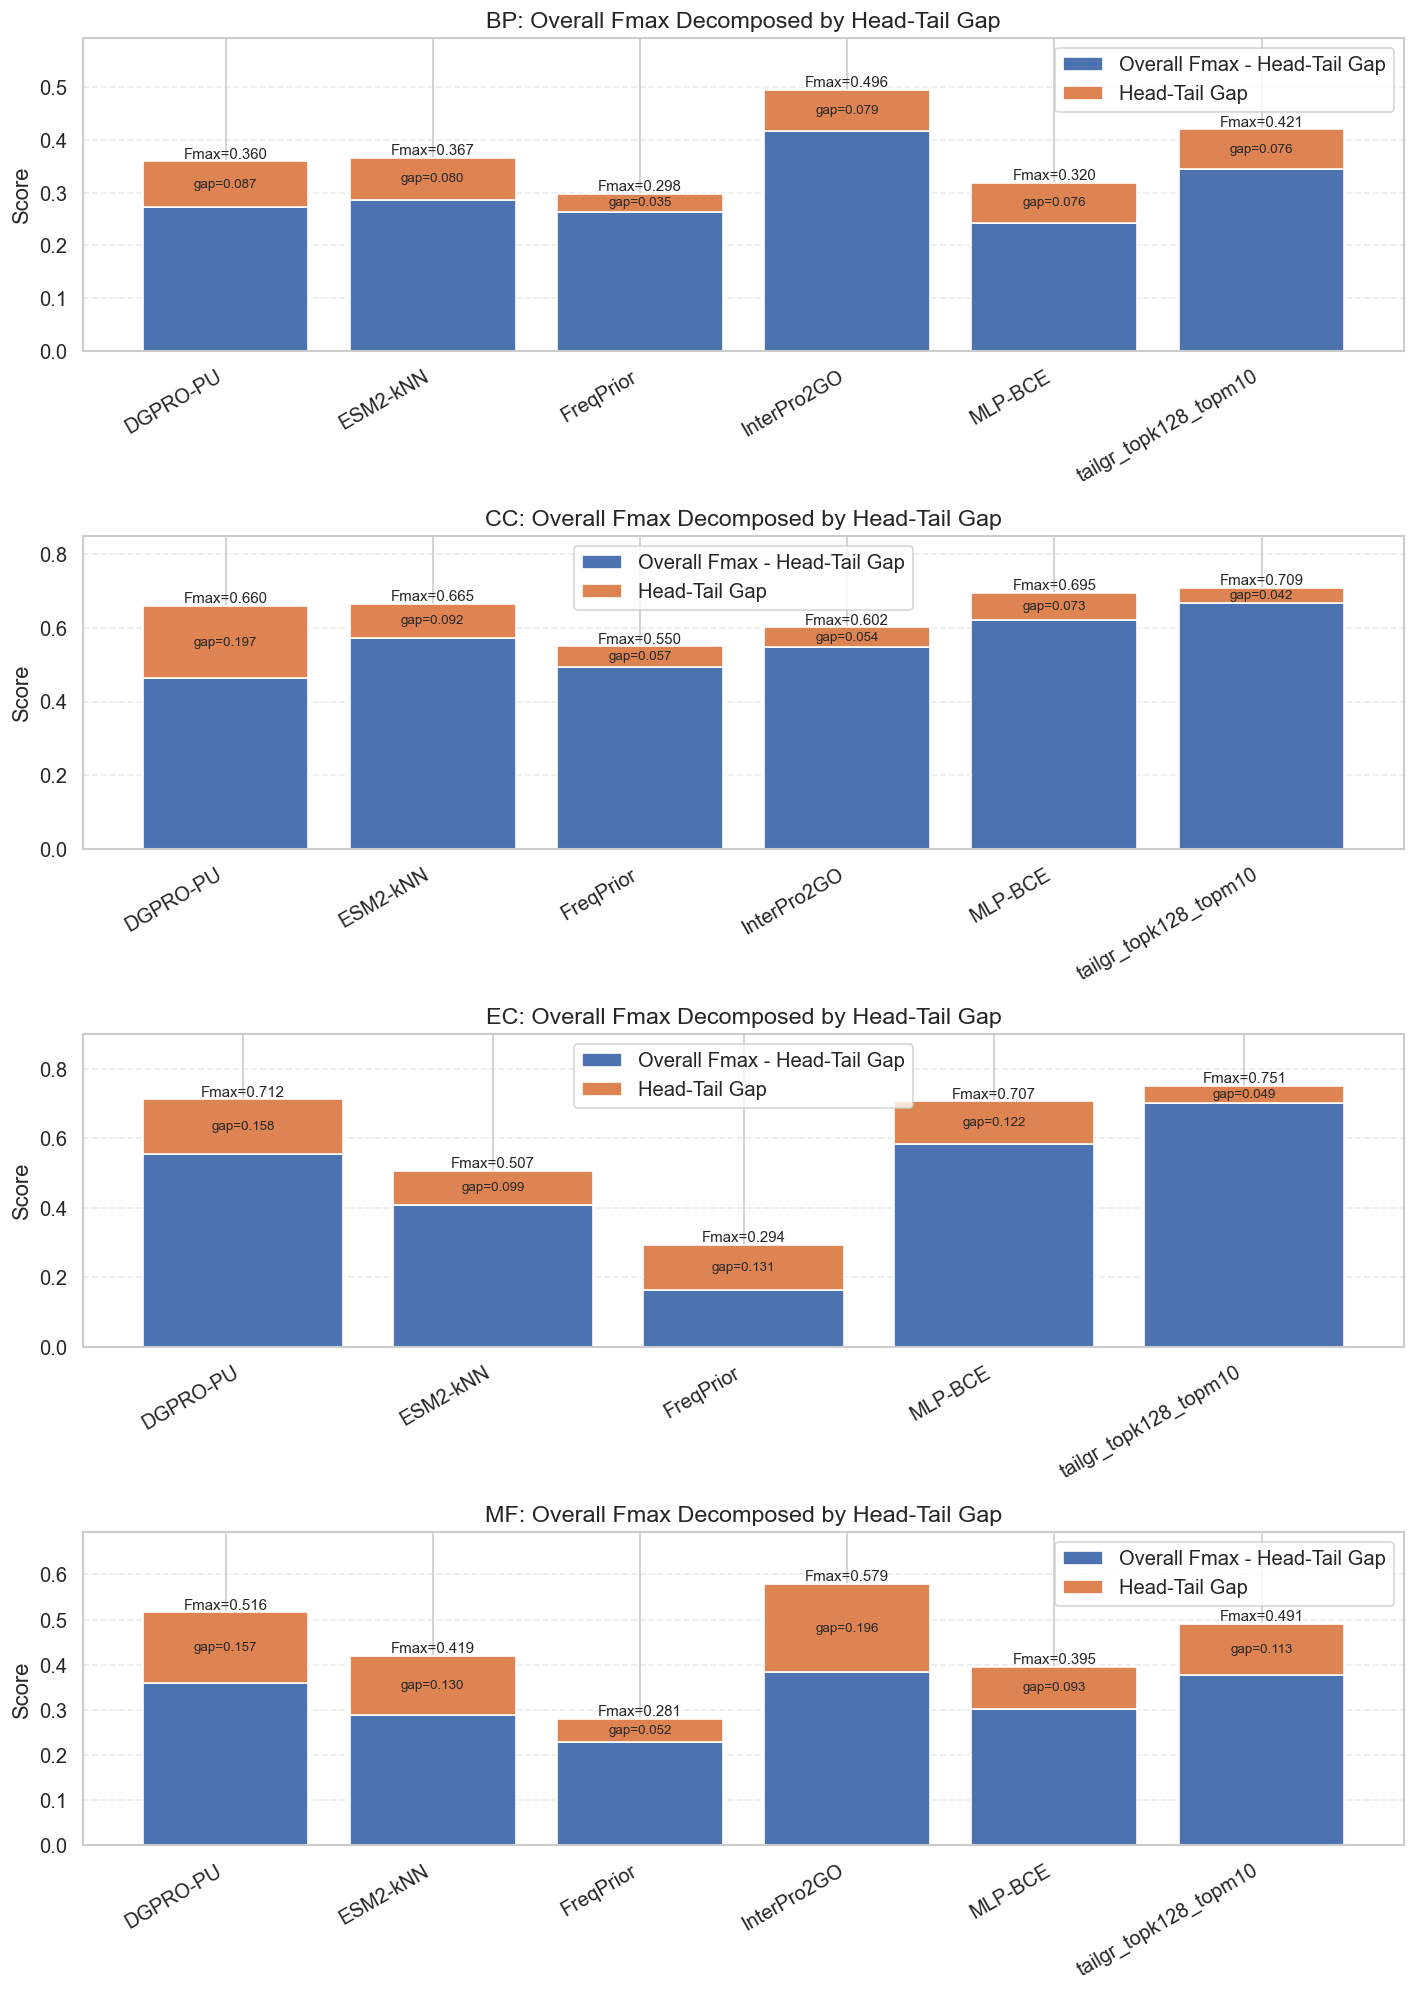

In [5]:
# ================================================================
# Figure 1: Stacked Bar Plot
# Lower part = Overall Fmax - Head-Tail Gap
# Upper part = Head-Tail Gap
# Total height = Overall Fmax
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------
# 1. 准备绘图数据
# ------------------------------------------------
plot_df = pivot_fmax.reset_index()

# 改列名：Official-Fmax -> Overall Fmax
plot_df = plot_df.rename(columns={"Official-Fmax": "Overall Fmax"})

hmt_df = pivot_hmt.reset_index()

plot_df = plot_df.merge(
    hmt_df[["ont", "model", "Macro-Fmax_head", "Macro-Fmax_tail"]],
    on=["ont", "model"],
    how="left"
)

plot_df["Head-Tail Gap"] = (
    plot_df["Macro-Fmax_head"] - plot_df["Macro-Fmax_tail"]
)

plot_df["Fmax_minus_Gap"] = (
    plot_df["Overall Fmax"] - plot_df["Head-Tail Gap"]
)

plot_df["Fmax_minus_Gap"] = plot_df["Fmax_minus_Gap"].clip(lower=0)

plot_df = plot_df.sort_values(["ont", "model"]).reset_index(drop=True)

print("\n=== Figure 1 Data: Stacked Overall Fmax ===")
print(
    plot_df[
        [
            "ont",
            "model",
            "Overall Fmax",
            "Head-Tail Gap",
            "Fmax_minus_Gap"
        ]
    ]
)

# ------------------------------------------------
# 2. 绘制累积柱状图
# ------------------------------------------------
onts = plot_df["ont"].unique()

fig, axes = plt.subplots(
    nrows=len(onts),
    ncols=1,
    figsize=(12, 4.2 * len(onts)),
    sharex=False
)

if len(onts) == 1:
    axes = [axes]

for ax, ont in zip(axes, onts):
    sub = plot_df[plot_df["ont"] == ont].copy()

    models = sub["model"].tolist()
    x = np.arange(len(models))

    lower = sub["Fmax_minus_Gap"].values
    upper = sub["Head-Tail Gap"].values
    total = sub["Overall Fmax"].values

    bars_lower = ax.bar(
        x,
        lower,
        label="Overall Fmax - Head-Tail Gap"
    )

    bars_upper = ax.bar(
        x,
        upper,
        bottom=lower,
        label="Head-Tail Gap"
    )

    ax.set_title(
        f"{ont}: Overall Fmax Decomposed by Head-Tail Gap",
        fontsize=14
    )

    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right")

    ax.set_ylim(0, total.max() * 1.20)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for i in range(len(x)):
        ax.text(
            x[i],
            total[i],
            f"Fmax={total[i]:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    for i in range(len(x)):
        ax.text(
            x[i],
            lower[i] + upper[i] / 2,
            f"gap={upper[i]:.3f}",
            ha="center",
            va="center",
            fontsize=8
        )

    ax.legend()

plt.tight_layout()

# ------------------------------------------------
# 3. 保存图片到同一个文件夹
# ------------------------------------------------
fig_path_png = OUT_DIR / "figure1_stacked_overall_fmax_gap.png"
fig_path_pdf = OUT_DIR / "figure1_stacked_overall_fmax_gap.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")

plt.show()


=== Per-term Frequency Analysis: EC ===
Missing: predict_result/ec_InterPro2GO.csv

=== Per-term Frequency Analysis: MF ===

=== Per-term Frequency Analysis: BP ===

=== Per-term Frequency Analysis: CC ===

=== Frequency vs Per-term Fmax Correlation ===
   ont                  model  SpearmanR_freq_vs_fmax        p_value  \
0   EC              FreqPrior                0.555286   3.003240e-17   
1   EC               ESM2-kNN                0.014939   8.353730e-01   
2   EC                MLP-BCE               -0.027597   7.010132e-01   
3   EC               DGPRO-PU                0.018060   8.016259e-01   
4   EC  tailgr_topk128_topm10               -0.108631   1.296203e-01   
5   MF              FreqPrior                0.535380   2.880518e-93   
6   MF            InterPro2GO                0.411663   4.159086e-52   
7   MF               ESM2-kNN                0.435876   6.937131e-59   
8   MF                MLP-BCE                0.295306   1.788920e-26   
9   MF               DGPR

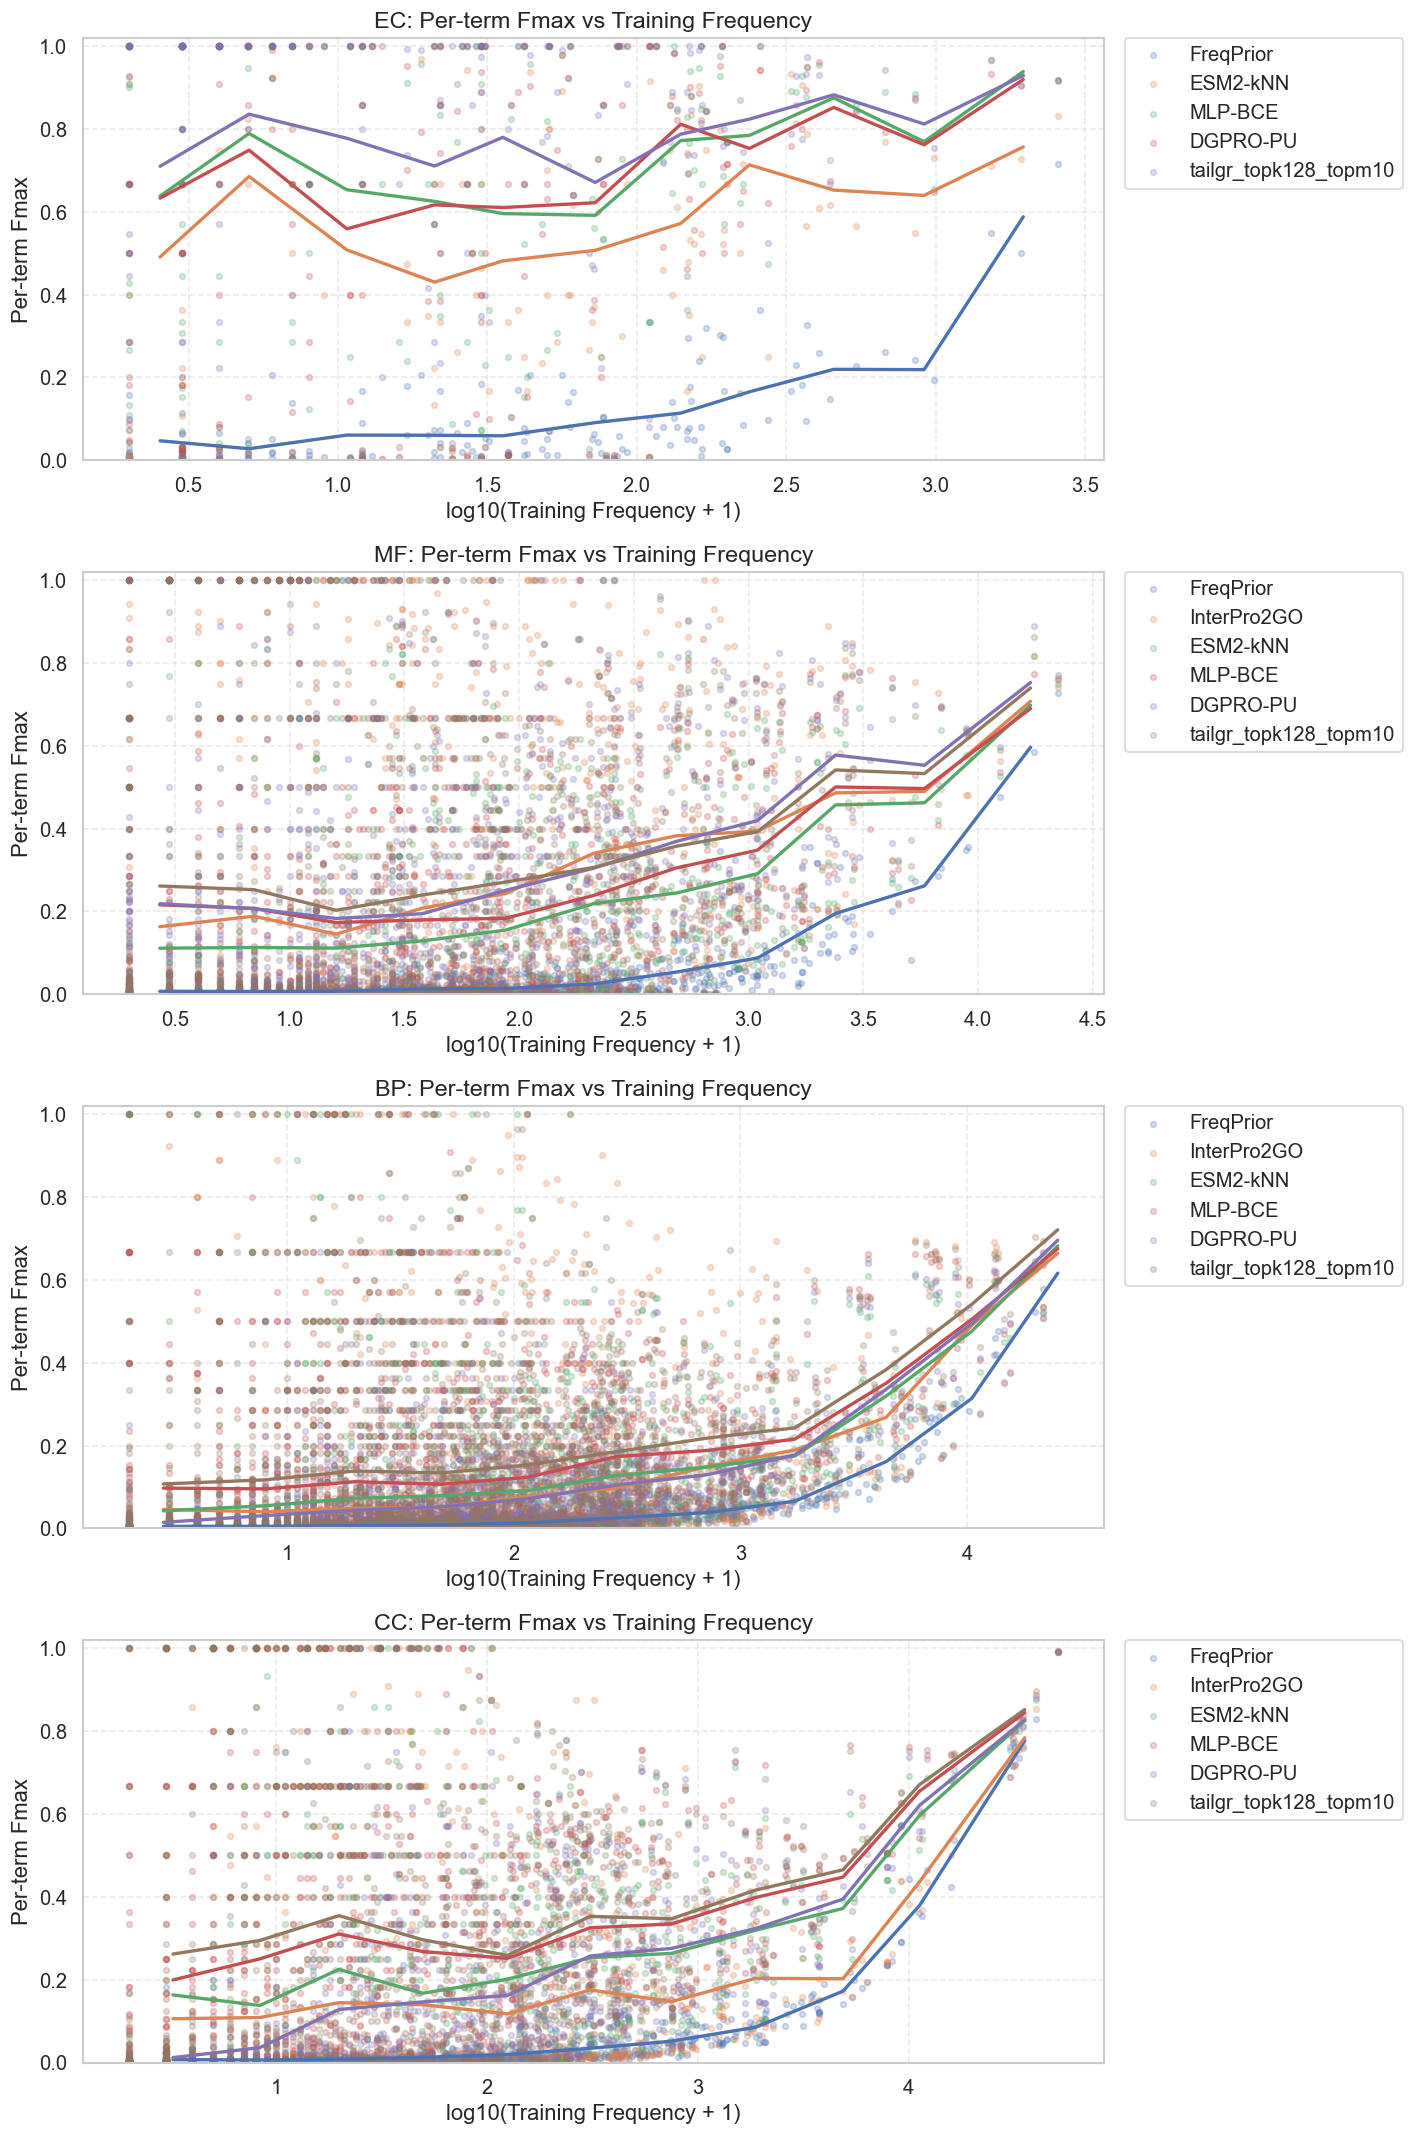

In [6]:
# ================================================================
# Figure 2: Per-term Performance vs Training Frequency
# ================================================================

from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ------------------------------------------------
# 1. 计算每个 term 的 Fmax 和训练频率
# ------------------------------------------------
term_perf_results = []
corr_results = []

for ont in ONTS:
    print(f"\n=== Per-term Frequency Analysis: {ont.upper()} ===")

    d = ONT_DATA[ont]
    labels = d["Yte"].numpy()
    freq = d["freq"]
    term_names = d["terms"]

    valid_terms = freq > 0

    for model in MODELS:
        file_path = f"{PRED_DIR}/{ont}_{model}.csv"

        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        df = pd.read_csv(file_path)
        preds = df.drop(columns=["protein_id"]).values

        # 和前面的评估保持一致：先做 ancestor propagation
        if ont == "ec":
            preds = propagate_ec_scores(preds, d["term2idx"])
        else:
            preds = propagate_pred_scores_official(
                preds,
                go_rels,
                d["term2idx"]
            )

        per_term_fmax = []

        for k in range(labels.shape[1]):
            if not valid_terms[k]:
                per_term_fmax.append(np.nan)
                continue

            val = compute_fmax_fast(preds[:, k], labels[:, k])
            per_term_fmax.append(val)

        per_term_fmax = np.array(per_term_fmax)

        # 只保留训练集中出现过，并且测试集中可以算 Fmax 的 term
        keep = valid_terms & (~np.isnan(per_term_fmax))

        if keep.sum() == 0:
            continue

        x = np.log10(freq[keep] + 1)
        y = per_term_fmax[keep]

        # Spearman correlation:
        # 越高说明性能越依赖训练频率
        if len(x) >= 2:
            rho, pval = spearmanr(x, y)
        else:
            rho, pval = np.nan, np.nan

        corr_results.append({
            "ont": ont.upper(),
            "model": model,
            "SpearmanR_freq_vs_fmax": rho,
            "p_value": pval,
            "num_terms": int(keep.sum())
        })

        for idx in np.where(keep)[0]:
            term_perf_results.append({
                "ont": ont.upper(),
                "model": model,
                "term": term_names[idx],
                "train_freq": int(freq[idx]),
                "log_train_freq": np.log10(freq[idx] + 1),
                "per_term_fmax": per_term_fmax[idx]
            })

df_term_perf = pd.DataFrame(term_perf_results)
df_corr = pd.DataFrame(corr_results)

print("\n=== Frequency vs Per-term Fmax Correlation ===")
print(df_corr)

# 保存相关系数表
corr_path = OUT_DIR / "table4_frequency_fmax_correlation.csv"
df_corr.to_csv(corr_path, index=False)
print(f"Saved: {corr_path}")

# 保存 per-term 数据，后续写论文或重新画图可以复用
term_perf_path = OUT_DIR / "table5_per_term_frequency_fmax.csv"
df_term_perf.to_csv(term_perf_path, index=False)
print(f"Saved: {term_perf_path}")


# ------------------------------------------------
# 2. 绘制 Per-term Performance vs Frequency 图
# ------------------------------------------------
onts = df_term_perf["ont"].unique()

fig, axes = plt.subplots(
    nrows=len(onts),
    ncols=1,
    figsize=(12, 4.5 * len(onts)),
    sharex=False,
    sharey=True
)

if len(onts) == 1:
    axes = [axes]

for ax, ont in zip(axes, onts):
    sub_ont = df_term_perf[df_term_perf["ont"] == ont].copy()

    for model in sub_ont["model"].unique():
        sub = sub_ont[sub_ont["model"] == model].copy()

        # 为了防止点太多导致图太乱，可以采样
        # 如果你想画全部点，把 sample_n 改成 len(sub)
        sample_n = min(len(sub), 2500)
        sub_plot = sub.sample(sample_n, random_state=SEED)

        ax.scatter(
            sub_plot["log_train_freq"],
            sub_plot["per_term_fmax"],
            s=12,
            alpha=0.25,
            label=model
        )

        # 平滑趋势线：按频率分箱后取平均
        bins = np.linspace(
            sub["log_train_freq"].min(),
            sub["log_train_freq"].max(),
            12
        )

        sub["freq_bin"] = pd.cut(
            sub["log_train_freq"],
            bins=bins,
            include_lowest=True
        )

        trend = sub.groupby("freq_bin", observed=True).agg(
            mean_log_freq=("log_train_freq", "mean"),
            mean_fmax=("per_term_fmax", "mean")
        ).dropna()

        ax.plot(
            trend["mean_log_freq"],
            trend["mean_fmax"],
            linewidth=2
        )

    ax.set_title(
        f"{ont}: Per-term Fmax vs Training Frequency",
        fontsize=14
    )
    ax.set_xlabel("log10(Training Frequency + 1)")
    ax.set_ylabel("Per-term Fmax")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="both", linestyle="--", alpha=0.4)

    # 图例放到右侧，防止挡住点
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

plt.tight_layout()

fig2_path_png = OUT_DIR / "figure2_per_term_fmax_vs_frequency.png"
fig2_path_pdf = OUT_DIR / "figure2_per_term_fmax_vs_frequency.pdf"

plt.savefig(fig2_path_png, dpi=300)
plt.savefig(fig2_path_pdf)

print(f"Saved: {fig2_path_png}")
print(f"Saved: {fig2_path_pdf}")

plt.show()

Saved: analysis_tables\figure2_ec_per_term_fmax_vs_frequency.png
Saved: analysis_tables\figure2_ec_per_term_fmax_vs_frequency.pdf


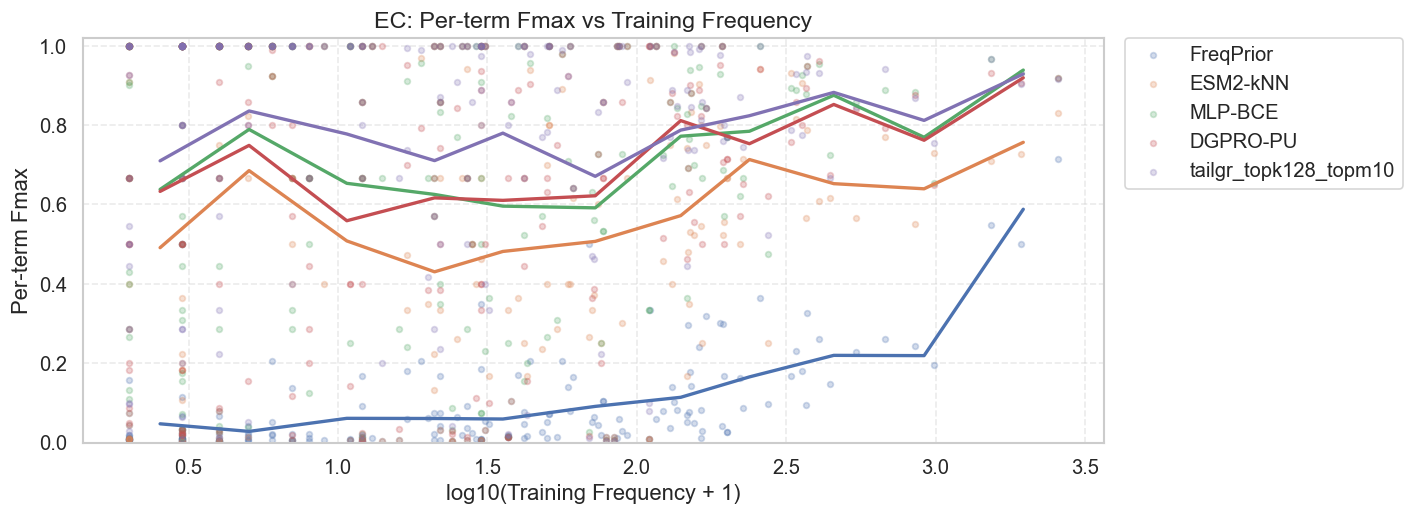

Saved: analysis_tables\figure2_cc_per_term_fmax_vs_frequency.png
Saved: analysis_tables\figure2_cc_per_term_fmax_vs_frequency.pdf


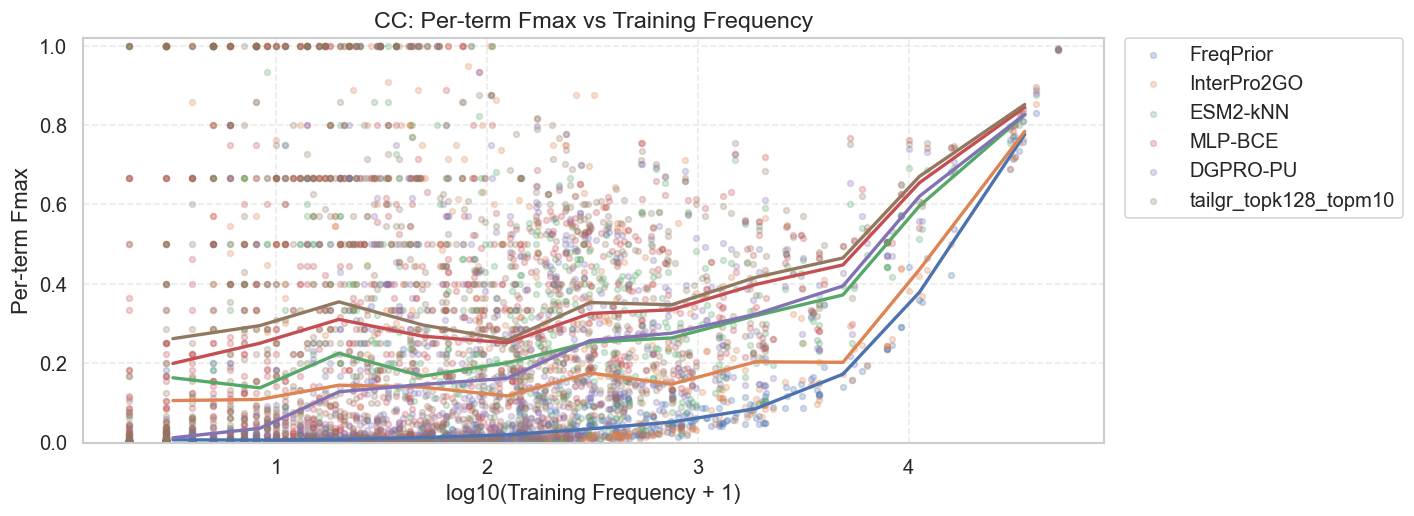

In [7]:
# ------------------------------------------------
# 3. 单独保存 EC 和 CC 图
# ------------------------------------------------
for target_ont in ["EC", "CC"]:
    ont_df = df_term_perf[df_term_perf["ont"] == target_ont].copy()

    fig, ax = plt.subplots(figsize=(12, 4.5))

    for model in ont_df["model"].unique():
        sub = ont_df[ont_df["model"] == model].copy()

        sample_n = min(len(sub), 2500)
        sub_plot = sub.sample(sample_n, random_state=SEED)

        ax.scatter(
            sub_plot["log_train_freq"],
            sub_plot["per_term_fmax"],
            s=12,
            alpha=0.25,
            label=model
        )

        bins = np.linspace(
            sub["log_train_freq"].min(),
            sub["log_train_freq"].max(),
            12
        )

        sub["freq_bin"] = pd.cut(
            sub["log_train_freq"],
            bins=bins,
            include_lowest=True
        )

        trend = sub.groupby("freq_bin", observed=True).agg(
            mean_log_freq=("log_train_freq", "mean"),
            mean_fmax=("per_term_fmax", "mean")
        ).dropna()

        ax.plot(
            trend["mean_log_freq"],
            trend["mean_fmax"],
            linewidth=2
        )

    ax.set_title(f"{target_ont}: Per-term Fmax vs Training Frequency", fontsize=14)
    ax.set_xlabel("log10(Training Frequency + 1)")
    ax.set_ylabel("Per-term Fmax")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="both", linestyle="--", alpha=0.4)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    fig_path_png = OUT_DIR / f"figure2_{target_ont.lower()}_per_term_fmax_vs_frequency.png"
    fig_path_pdf = OUT_DIR / f"figure2_{target_ont.lower()}_per_term_fmax_vs_frequency.pdf"

    plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
    plt.savefig(fig_path_pdf, bbox_inches="tight")

    print(f"Saved: {fig_path_png}")
    print(f"Saved: {fig_path_pdf}")

    plt.show()